In [1]:
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plts

from pmt.io import *

from pmt.preprocessing import *
from pmt.config import *
from pmt.plotting import *
from pmt.selection import *

plt.rcParams.update({
    "figure.figsize": (8, 5),
    "axes.grid": True,
    "grid.alpha": 0.70,
})


# Select Files


In [ ]:
data_dir = Path("data/WA0089/LED_sweep/260625/850V_525MHz")
channel = "Channel 2"

# file_name = "led_080"
# file_name = "led_100"
# file_name = "led_120"
# file_name = "led_140"
# file_name = "led_160"
# file_name = "led_180"

# Set to a number for quick iteration, or None to use all matching files.
max_files = None

files = find_pmt_files(data_dir, file_name, max_files=max_files)

files = files[1:2]


for file in files:
    print(file)
print(f"Number of files loaded: {len(files)}")


basic_plots=False # speed up notebook


data/WA0089/LED_sweep/260625/850V_525MHz/led_140-10.h5
Number of files loaded: 1


### if and where to save plots

In [3]:
save_plots = False
save_dir = 'plots_selection'
file_nickname = file_name

# Configuration

In [4]:
# cfg = load_config("config_default.yml", file_name)
# print(cfg)

In [5]:
chunk_size = 512 
baseline_window_width_ns = 20
basic_plots=True
time_origin="zero" # "orginal" or "zero"

In [6]:
max_sample_events = 2

sample = read_waveform_sample(files, max_events=max_sample_events, channel=channel, time_origin=time_origin)
time_ns = sample["time_ns"]
adc_step_mV = sample["adc_step_mV"]

print(f"Time range: {time_ns[0]:.3f} to {time_ns[-1]:.3f} ns")
print(f"Sampling step: {np.median(np.diff(time_ns)):.5f} ns")
print(f"ADC step: {adc_step_mV:.6f} mV\n")

baseline_window_ns = (float(time_ns[0]), float(time_ns[0] + baseline_window_width_ns))

Time range: 0.000 to 100.000 ns
Sampling step: 0.01562 ns
ADC step: 0.000255 mV



In [7]:
sample['metadata'][0].keys()

dict_keys(['filename', 'file_type', 'frame', 'channel', 'channel_attrs', 'segment_numbers', 'layout', 'time_tags', 'x_origins', 'segment_attrs'])

# 2. Full Sample


In [8]:
prerocessed_data = load_preprocessed_waveforms(
    files,
    chunk_size=chunk_size,
    remove_saturation=True,
    subtract_baseline=True,
    baseline_window_ns=baseline_window_ns,
    low_limit_mV=None, 
    high_limit_mV=None, 
    margin_mV=0.0,
    max_saturated_samples=0,
    channel=channel,
    time_origin=time_origin, # "orginal" or "zero"
)

time_ns = prerocessed_data["time_ns"]
voltage_mV = prerocessed_data["voltage_mV"]

print(f"Preprocessed sample: {prerocessed_data["voltage_mV"].shape}")
print(f"Efficiency of saturation cut: {prerocessed_data['saturation_summary']['efficiency']*100:.3f} %")
print(f"N raw events: {prerocessed_data['saturation_summary']['n_total']}")

remove = ['is_saturated', 'n_saturated_samples']
preprocessed_event_info = {k: v for k, v in prerocessed_data['event_info'].items() if k not in remove}
preprocessed_event_info.update({ 
    'event_file': prerocessed_data['event_file'],
    'event_segment': prerocessed_data['event_segment']
})

print(prerocessed_data.keys())
print()
print(f"prerocessed_data['event_info']: {prerocessed_data['event_info'].keys()}")


Preprocessed sample: (31000, 6401)
Efficiency of saturation cut: 100.000 %
N raw events: 31000
dict_keys(['time_ns', 'voltage_mV', 'event_file', 'event_segment', 'event_info', 'saturation_summary'])

prerocessed_data['event_info']: dict_keys(['is_saturated', 'n_saturated_samples', 'baseline_mean_mV', 'baseline_rms_mV', 'baseline_slope_mV_per_ns'])


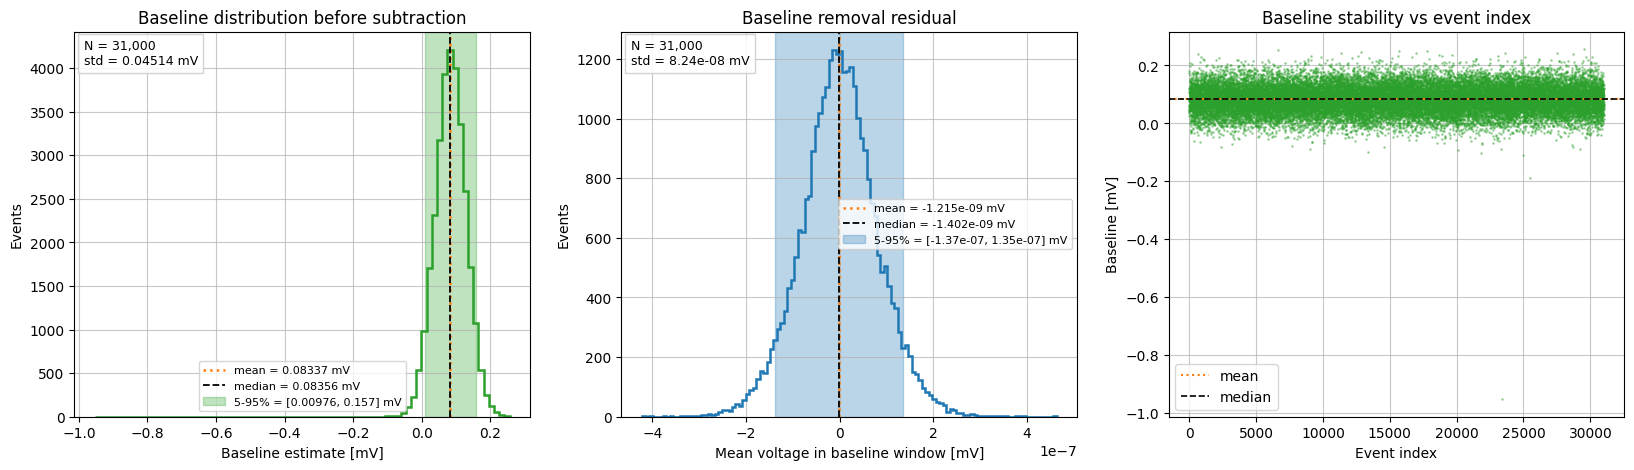

In [9]:
if basic_plots:
    fig, axes = plt.subplots(1, 3, figsize=(20, 5))
    plot_baseline_quality(axes, time_ns, prerocessed_data['event_info']['baseline_mean_mV'], voltage_mV, baseline_window_ns)
    save_plot(fig, save_plots, save_dir, file_nickname, f"basline_quality",  Nevents=None)

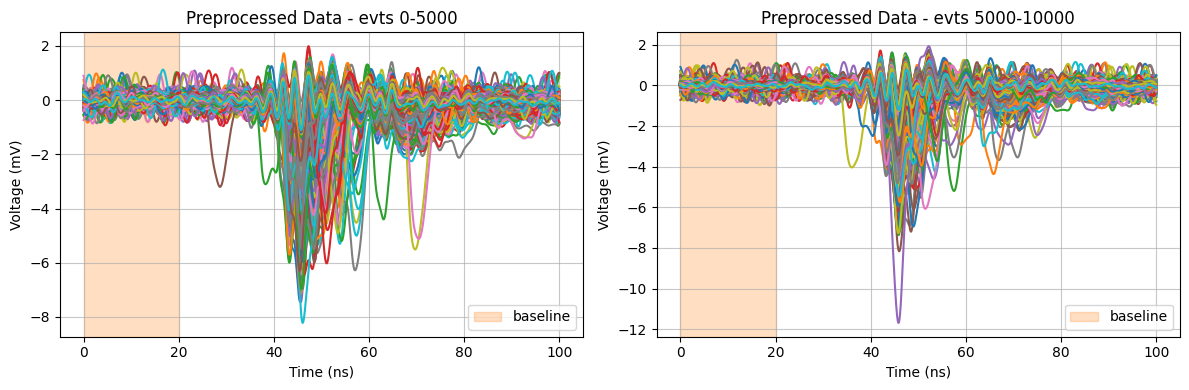

In [33]:
if basic_plots:
    
    n_to_plot = 5000
    fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharex=True)
    add_plot_waveforms(axes[0], time_ns, voltage_mV[:n_to_plot], title=f"Preprocessed Data - evts 0-{n_to_plot}")
    axes[0].axvspan(*baseline_window_ns, color="tab:orange", alpha=0.25, label="baseline")
    axes[0].legend(loc="lower right")

    add_plot_waveforms(axes[1], time_ns, voltage_mV[n_to_plot:2*n_to_plot], title=f"Preprocessed Data - evts {n_to_plot}-{2*n_to_plot}")
    axes[1].axvspan(*baseline_window_ns, color="tab:orange", alpha=0.25, label="baseline")
    axes[1].legend(loc="lower right")

    fig.tight_layout()
    save_plot(fig, save_plots, save_dir, file_nickname,"few_waveforms", Nevents=n_to_plot);

In [11]:
df = build_waveform_feature_dataframe(
    time_ns,
    voltage_mV,
    peak_threshold_mV=None,
    second_peak_min_height_frac=0.2,
    pre_peak_ns = 20,
    post_peak_ns = 80,
    pre_rise_ns = 10, 
    post_rise_ns = 80, 
    extra=preprocessed_event_info # extra dictionary to be added to the dataframe
)




/Users/emiliebertholet/Desktop/Lab/TAU-neutrino-lab_git-repos/PMT-characterization/PMT-calibration/pmt/preprocessing.py:317: PeakPropertyWarning: some peaks have a prominence of 0
  widths, _, _, _ = peak_widths( v, [pk], rel_height=0.5 )
/Users/emiliebertholet/Desktop/Lab/TAU-neutrino-lab_git-repos/PMT-characterization/PMT-calibration/pmt/preprocessing.py:317: PeakPropertyWarning: some peaks have a width of 0
  widths, _, _, _ = peak_widths( v, [pk], rel_height=0.5 )


# Selection

## 1. remove waveforms that peak in the baseline window

In [12]:

cutflow = CutFlow(len(df))

peaks_in_basleinewindow = reject_baseline_pulses( df, baseline_window_ns, min_peak_height_mV=0.5 )
cutflow.apply( "peaks in the baseline", reject_baseline_pulses( df, baseline_window_ns, min_peak_height_mV=0.5 ) )
# cutflow.apply( "SNR > 5", df["snr"] > 5 )
# cutflow.apply( "Single peak", df["n_peaks"] == 1 )
cutflow.print()

df_sel = df[cutflow.mask].copy()
waveforms_sel = voltage_mV[cutflow.mask]


df_sel.shape


Cut                            Kept    Relative    Cumulative
--------------------------------------------------------------
Initial                       31000      100.0%        100.0%
peaks in the baseline         30984       99.9%         99.9%


(30984, 33)

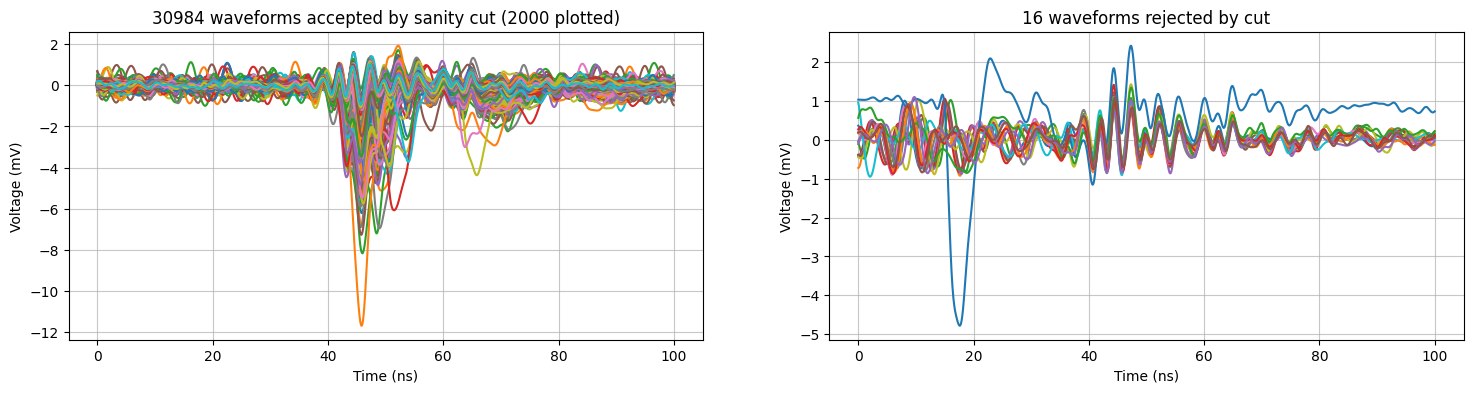

In [13]:
if basic_plots:
    evts_plot = (8000, 10000)
    fig, axes = plt.subplots(1, 2, figsize=(18, 4))
    axes = axes.ravel()
    rejected_waveforms = voltage_mV[~peaks_in_basleinewindow.values]
    add_plot_waveforms(axes[0], time_ns, waveforms_sel[evts_plot[0]:evts_plot[1]], title=f"{len(waveforms_sel)} waveforms accepted by sanity cut ({evts_plot[1]-evts_plot[0]} plotted)")
    add_plot_waveforms(axes[1], time_ns, rejected_waveforms, title=f"{len(rejected_waveforms)} waveforms rejected by cut")
    save_plot(fig, save_plots, save_dir, file_nickname, f"waveforms_after_sanity_cut",  Nevents=None)

## 2. Remove backrounds based on peak timing

In [14]:
# late/early definitions
early_peak = (45.2, 45.9)
late_peak  = (53.5, 54.1)
time_peak_range = (40, 60)

early_mask = df_sel["peak_time_ns"].between(early_peak[0], early_peak[1])
late_mask = df_sel["peak_time_ns"].between(late_peak[0], late_peak[1])

df_early = df_sel.loc[early_mask, :].copy()
df_late = df_sel.loc[late_mask, :].copy()



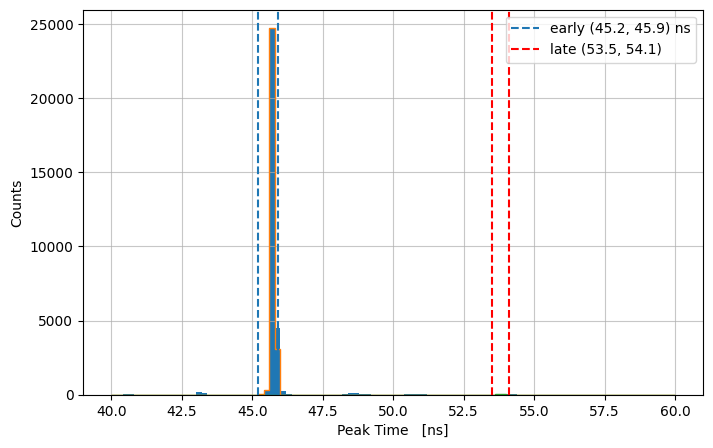

In [35]:
rg = time_peak_range
plt.hist(df_sel["peak_time_ns"], bins=100, range=rg);
plt.hist(df_early["peak_time_ns"], bins=100, range=rg, histtype='step');
plt.hist(df_late["peak_time_ns"], bins=100, range=rg, histtype='step');
plt.axvline(x = early_peak[0], linestyle='dashed', label=f'early {early_peak} ns')
plt.axvline(x = early_peak[1], linestyle='dashed')
plt.axvline(x = late_peak[0], linestyle='dashed', color='red', label=f'late {late_peak}')
plt.axvline(x = late_peak[1], linestyle='dashed', color='red');
plt.legend(loc='upper right')
plt.xlabel("Peak Time   [ns]")
plt.ylabel("Counts");

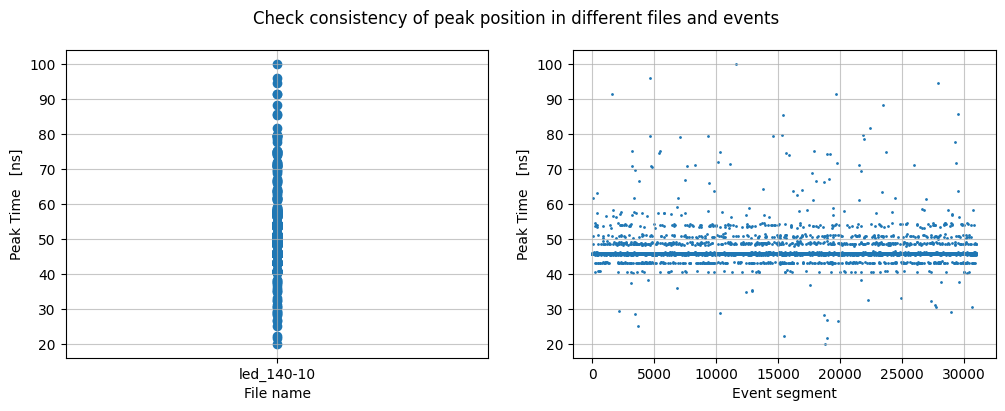

In [16]:
fig, axes = plt.subplots(1,2, figsize=(12,4))
fig.suptitle('Check consistency of peak position in different files and events')
axes = axes.ravel()

df_sel["file"] = (df_sel["event_file"].str.rsplit("/", n=1).str[-1].str.removesuffix(".h5"))
axes[0].scatter( df_sel["file"], df_sel["peak_time_ns"] );
axes[0].set_xlabel('File name');
axes[0].set_ylabel("Peak Time   [ns]");

df_sel.groupby("event_file")["peak_time_ns"].value_counts()
axes[1].scatter(
    df_sel["event_segment"],
    df_sel["peak_time_ns"],
    s=1,
)
axes[1].set_xlabel('Event segment');
axes[1].set_ylabel("Peak Time   [ns]");

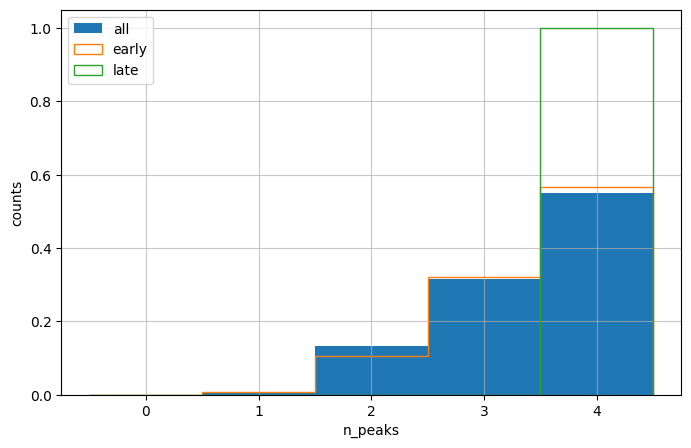

In [17]:


den=True
plt.hist(df_sel["n_peaks"], bins=np.arange(6)-0.5,density=den, label='all');
plt.hist(df_early["n_peaks"], bins=np.arange(6)-0.5, histtype='step',density=den, label='early');
plt.hist(df_late["n_peaks"], bins=np.arange(6)-0.5, histtype='step',density=den, label='late');
plt.xlabel('n_peaks')
plt.ylabel('counts')
plt.legend();


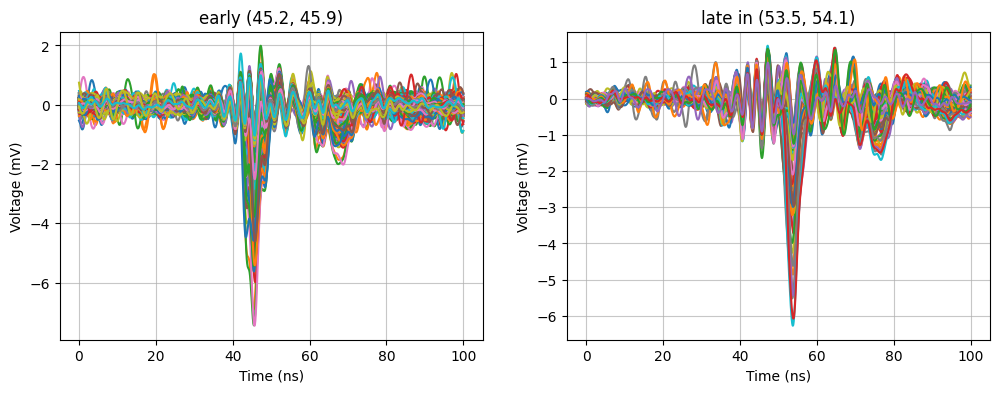

In [18]:

evts=(0, 2000)
fig, axes = plt.subplots(1,2, figsize=(12,4))
add_plot_waveforms(axes[0], time_ns, waveforms_sel[early_mask.values][evts[0]:evts[1]], title=f"early {early_peak}")
add_plot_waveforms(axes[1], time_ns, waveforms_sel[late_mask.values][evts[0]:evts[1]], title=f"late in {late_peak}")



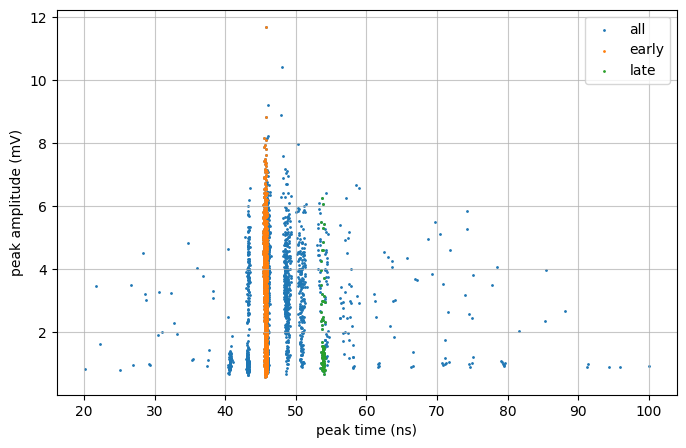

In [19]:
plt.scatter( df_sel["peak_time_ns"], df_sel["peak_amplitude_mV"], s=1, label='all' );
plt.scatter( df_early["peak_time_ns"], df_early["peak_amplitude_mV"], s=1, label='early' );
plt.scatter( df_late["peak_time_ns"], df_late["peak_amplitude_mV"], s=1, label='late' );
plt.xlabel('peak time (ns)')
plt.ylabel('peak amplitude (mV)')
plt.legend();




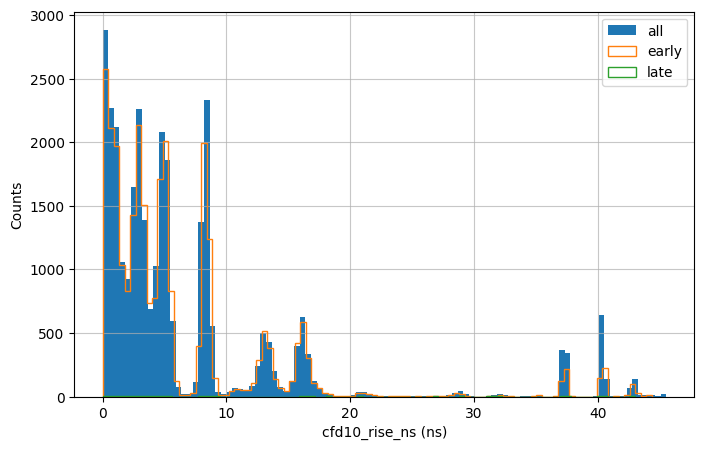

In [ ]:
plt.hist(df_sel["cfd10_rise_ns"],   bins=100, label='all' );
plt.hist(df_early["cfd10_rise_ns"], bins=100, label='early', histtype='step' );
plt.hist(df_late["cfd10_rise_ns"],  bins=100, label='late',  histtype='step' );
plt.xlabel('cfd10_rise_ns (ns)');
plt.ylabel('Counts')
plt.legend();


In [21]:
np.mean(np.diff(time_ns)) # sampling period


np.float64(0.015625000000000003)

In [22]:
print(early_mask.mean(), late_mask.mean())

0.908694810224632 0.0027433514071778984


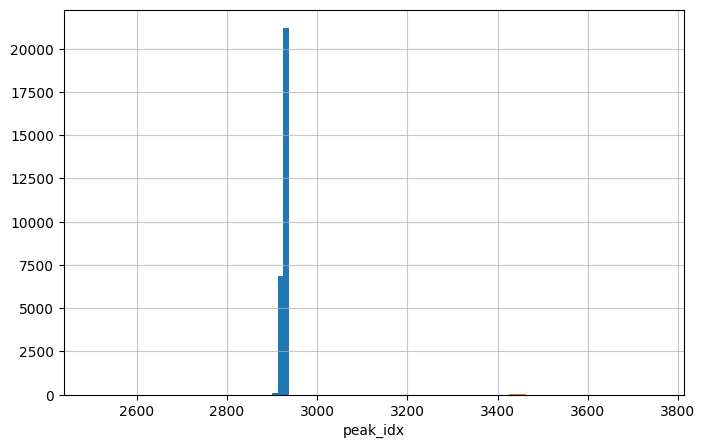

In [23]:
rg = (2500, 3750)
plt.hist(df_early.peak_idx, bins=100, range=rg, label='early');
plt.hist(df_late.peak_idx, bins=100, range=rg, label='late');
plt.xlabel('peak_idx');

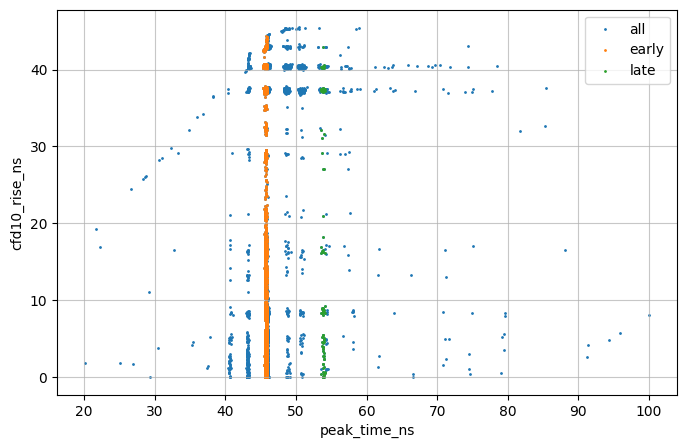

In [24]:
plt.scatter( df_sel["peak_time_ns"], df_sel["cfd10_rise_ns"], s=1, label='all'  )
plt.scatter( df_early["peak_time_ns"], df_early["cfd10_rise_ns"], s=1, label='early' );
plt.scatter( df_late["peak_time_ns"], df_late["cfd10_rise_ns"], s=1, label='late' );
plt.xlabel('peak_time_ns')
plt.ylabel('cfd10_rise_ns');
plt.legend();


In [25]:
dt = np.mean(np.diff(time_ns))
print(dt)
print(550 * dt)

0.015625000000000003
8.593750000000002


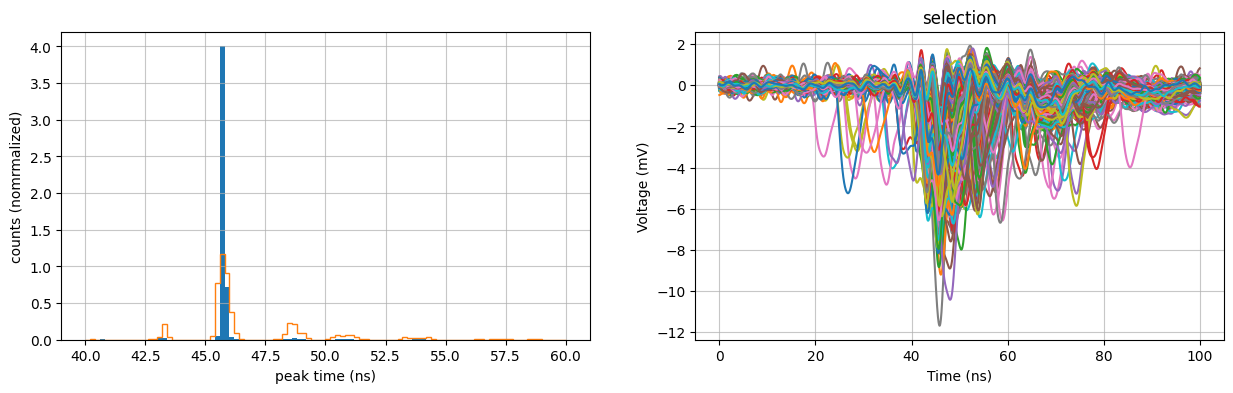

In [44]:
#---- cuts
# mask = df_sel.snr > 10
mask = df_sel.peak_amplitude_mV > 3.0

fig, axes = plt.subplots(1,2, figsize=(15,4))

rg = time_peak_range
den=True
axes[0].hist(df_sel["peak_time_ns"], bins=100, range=rg, density=den);
axes[0].hist(df_sel.loc[mask, "peak_time_ns"], bins=100, range=rg, histtype='step', density=den);
axes[0].set_xlabel('peak time (ns)')
axes[0].set_ylabel('counts (nomrmalized)');

evts=(0, 2000)
add_plot_waveforms(axes[1], time_ns, waveforms_sel[mask][evts[0]:evts[1]], title=f"selection")

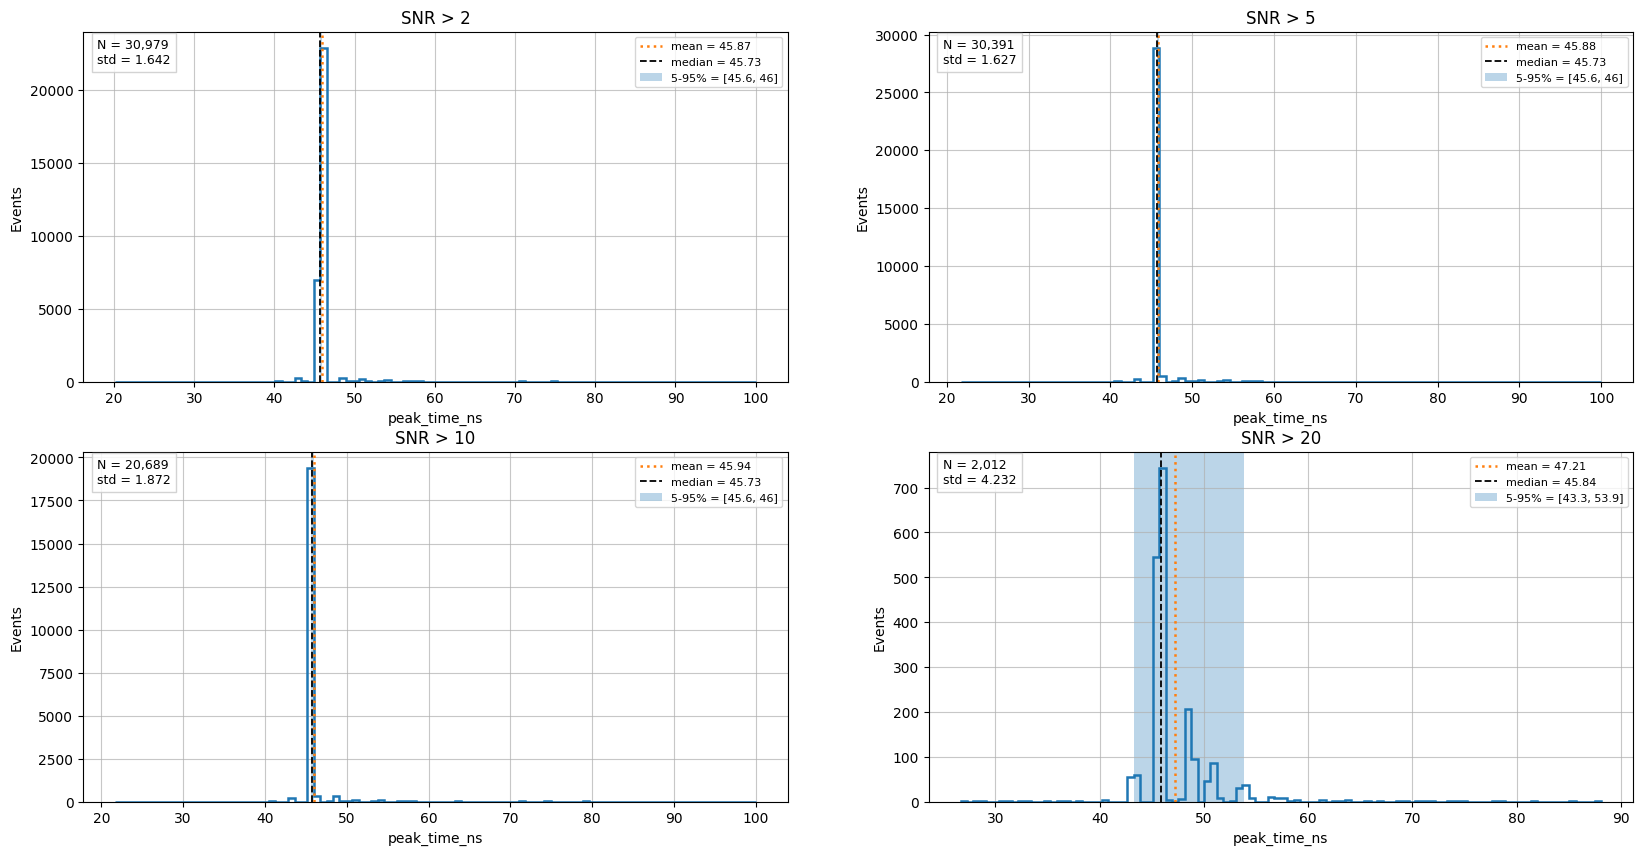

In [27]:
fig, axes = plt.subplots(2, 2, figsize=(20, 10))
axes = axes.ravel()

snr_cuts = [2, 5, 10, 20]
for i in range(0, len(snr_cuts)):
    add_hist_stats(axes[i], df_sel.loc[df_sel.snr > snr_cuts[i], "peak_time_ns"], 100, None, 'peak_time_ns', f'SNR > {snr_cuts[i]}', unit="", show_stat=True, text_position=(0.02, 0.98), legend_loc="best")


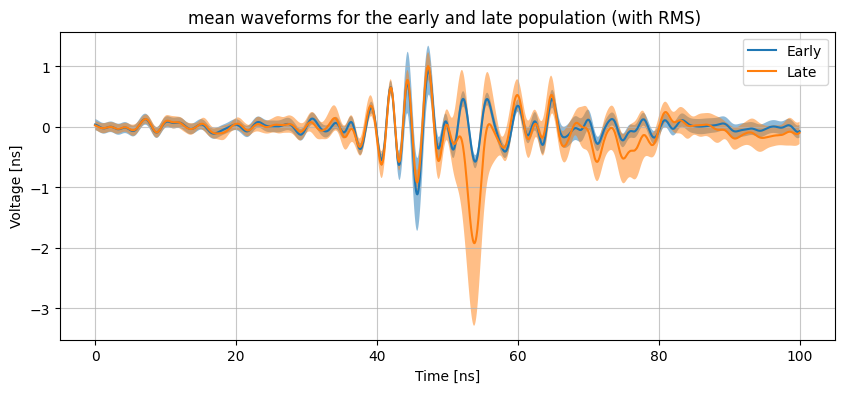

In [28]:
early = df_sel["peak_time_ns"].between(35.2, 35.8)
late  = df_sel["peak_time_ns"].between(43.5, 44.1)

fig, ax = plt.subplots(figsize=(10,4))

add_mean_waveform(
    ax,
    time_ns,
    waveforms_sel[early_mask.values],
    label="Early",
)

add_mean_waveform(
    ax,
    time_ns,
    waveforms_sel[late_mask.values],
    label="Late",
)
ax.set_xlabel('Time [ns]')
ax.set_ylabel('Voltage [ns]')
ax.set_title('mean waveforms for the early and late population (with RMS) ')

ax.legend()

## SNR

[]

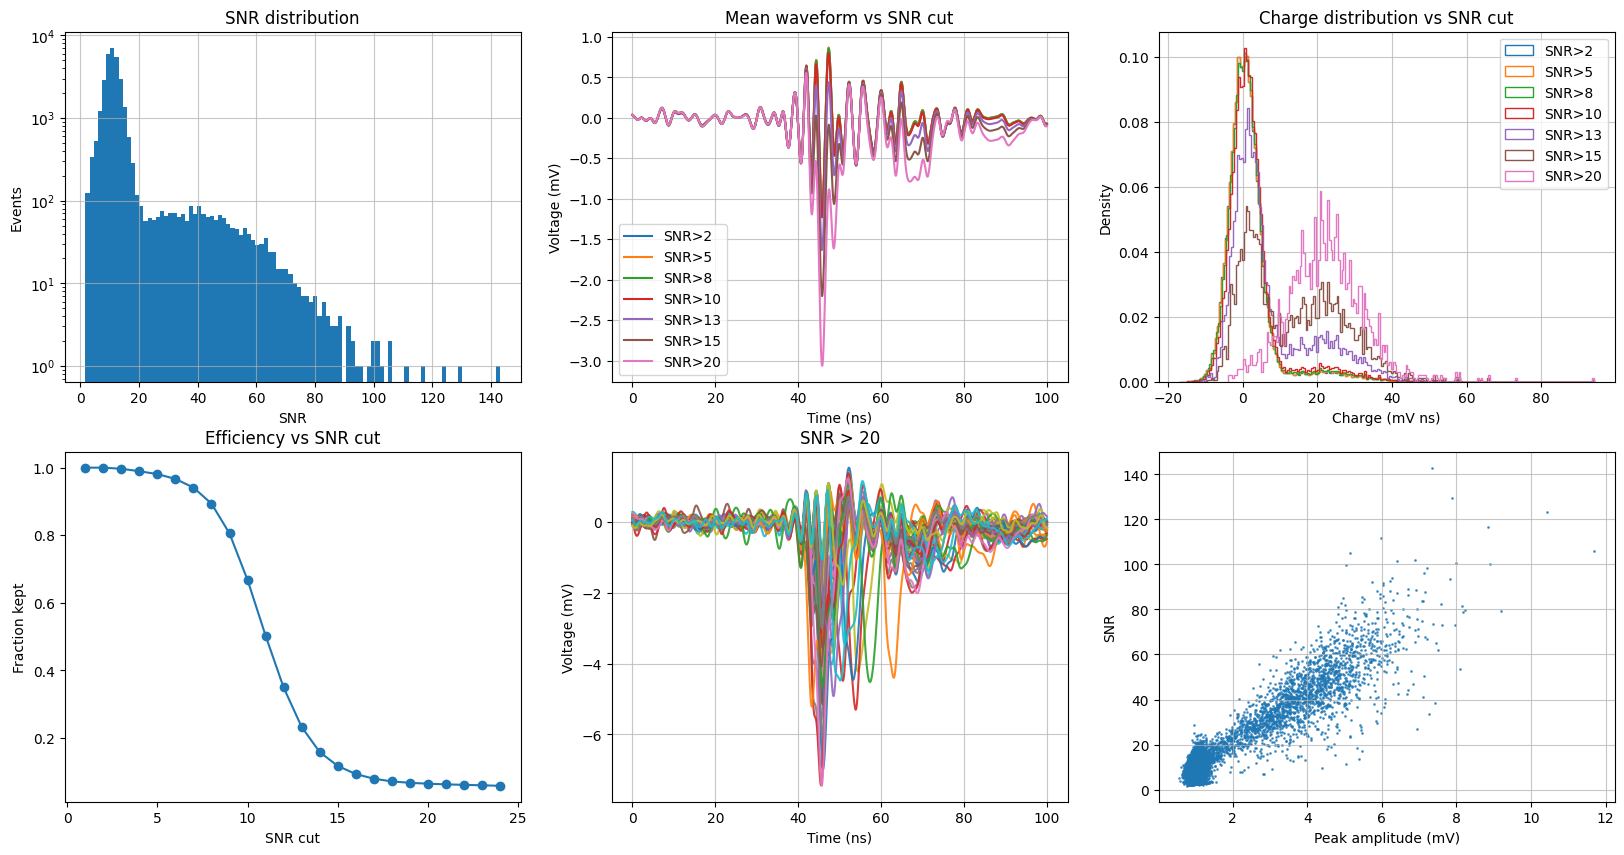

In [29]:
fig, axes = plt.subplots(2, 3, figsize=(20, 10))
axes = axes.ravel()
plot_snr_distribution(axes[0], df_sel)
plot_mean_waveforms_vs_snr(axes[1], df_sel, waveforms_sel, time_ns, cuts=(2, 5, 8, 10, 13, 15, 20))
plot_charge_histograms_vs_snr(axes[2], df_sel, cuts=(2, 5, 8, 10, 13, 15, 20))
plot_snr_efficiency(axes[3], df_sel, cuts=np.arange(1, 25))
plot_waveforms_in_snr_range( axes[4],  df_sel, waveforms_sel, time_ns, snr_min=20, snr_max=None, n_waveforms=50)  
plot_snr_vs_amplitude(axes[5], df_sel)  
save_plot(fig, save_plots, save_dir, file_nickname, f"snr_repport",  Nevents=None)

# Charge Computation

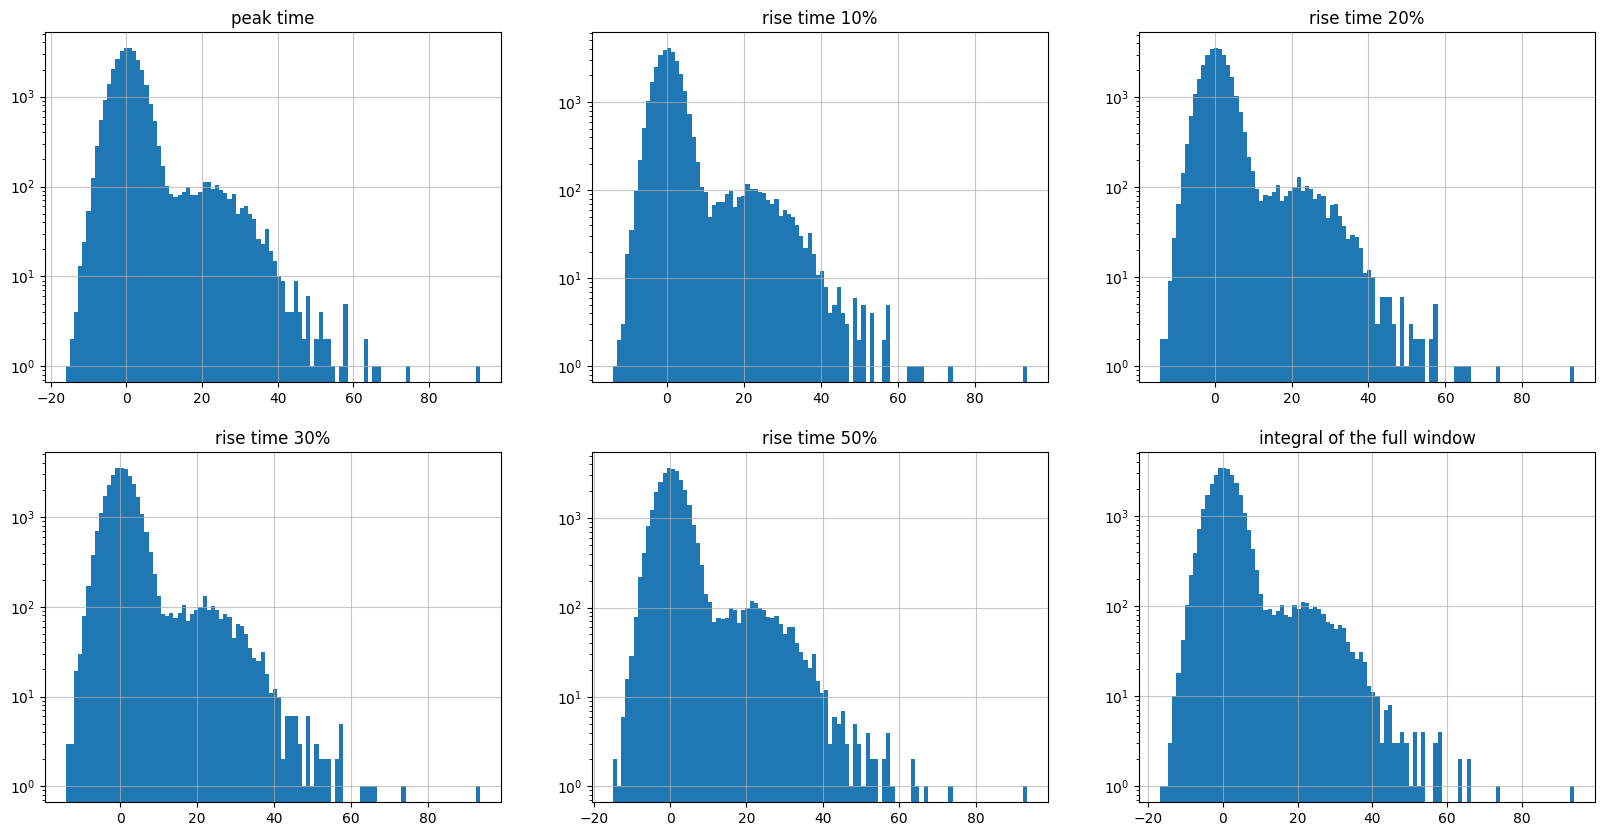

In [30]:
fig, axes = plt.subplots(2, 3, figsize=(20, 10))
axes = axes.ravel()

rg = None #(-20, 10)

axes[0].hist(df_sel.charge_peak_window_mV_ns, bins=100, range=rg);
axes[0].set_title("peak time")
axes[1].hist(df_sel.charge_cfd10_window_mV_ns, bins=100, range=rg);
axes[1].set_title("rise time 10%");
axes[2].hist(df_sel.charge_cfd20_window_mV_ns, bins=100, range=rg);
axes[2].set_title("rise time 20%");
axes[3].hist(df_sel.charge_cfd30_window_mV_ns, bins=100, range=rg);
axes[3].set_title("rise time 30%");
axes[4].hist(df_sel.charge_cfd50_window_mV_ns, bins=100, range=rg);
axes[4].set_title("rise time 50%");
axes[5].hist(df_sel.area_mV_ns, bins=100, range=rg);
axes[5].set_title("integral of the full window");

for i in range(0, 6):
    axes[i].set_yscale('log')


[]

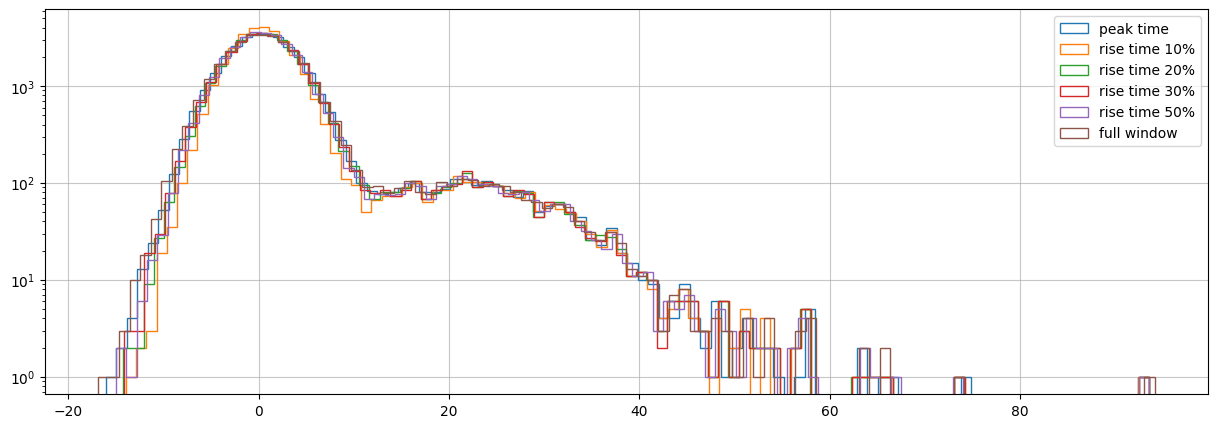

In [31]:
fig, axes = plt.subplots(1, 1, figsize=(15, 5))


rg = None #(-20, 10)
den=False

axes.hist(df_sel.charge_peak_window_mV_ns,  bins=100, range=rg, density=den, histtype='step', label="peak time");
axes.hist(df_sel.charge_cfd10_window_mV_ns, bins=100, range=rg, density=den, histtype='step', label="rise time 10%");
axes.hist(df_sel.charge_cfd20_window_mV_ns, bins=100, range=rg, density=den, histtype='step', label="rise time 20%");
axes.hist(df_sel.charge_cfd30_window_mV_ns, bins=100, range=rg, density=den, histtype='step', label="rise time 30%");
axes.hist(df_sel.charge_cfd50_window_mV_ns, bins=100, range=rg, density=den, histtype='step', label="rise time 50%");
axes.hist(df_sel.area_mV_ns, bins=100, range=rg, density=den, histtype='step', label="full window");
axes.set_yscale('log');
axes.legend();

save_plot(fig, save_plots, save_dir, file_nickname, f"charge_all_methods",  Nevents=None)

